In [2]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [16]:
# TASK 1 - Data Processing

"""
Loads eng/xho/sna splits, cleans + tokenises headline+text, and builds
TF-IDF feature matrices for a multinomial logistic regression model.
"""

import os
import re
import joblib
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder

DATA_DIR = "data"
OUT_DIR = "features"
LANGS = ["eng", "xho", "sna"]
SPLITS = ["train", "dev", "test"]

URL_RE = re.compile(r"https?://\S+|www\.\S+")
DIGIT_RE = re.compile(r"\d+")
TOKEN_RE = re.compile(r"<num>|[a-z]+")  #keep words and the special <num> token + text is lowercased before this runs


def load_split(lang, split):
    df = pd.read_csv(os.path.join(DATA_DIR, lang, f"{split}.tsv"), sep="\t")
    df["full_text"] = df["headline"].fillna("") + " " + df["text"].fillna("") # combine the headline & article text into one document
    return df[["category", "full_text"]]


def load_language(lang):
    return {split: load_split(lang, split) for split in SPLITS}


def clean_text(text):
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = DIGIT_RE.sub(" <num> ", text)  # keep "has a number" signal without huge vocab
    return text


def tokenize(text):
    # same simple tokenizer for all 3 languages - no stemmer/stopword list
    # exists for xho/sna so we don't want to give eng special treatment
    return TOKEN_RE.findall(clean_text(text))


def build_vectorizer(method="tfidf"):
    # same cleaning/tokenizing/ngrams for both, so the only thing that
    # differs is count-based vs tfidf-weighted features
    common = dict(
        tokenizer=tokenize,
        lowercase=False,
        token_pattern=None,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
    )
    if method == "tfidf":
        return TfidfVectorizer(sublinear_tf=True, **common)
    elif method == "bow":
        return CountVectorizer(**common)
    else:
        raise ValueError(f"unknown method: {method}")


def process_language(lang, method="tfidf"):
    print(f"=== {lang} ({method}) ===")
    data = load_language(lang)

    vectorizer = build_vectorizer(method)
    X_train = vectorizer.fit_transform(data["train"]["full_text"])  # fit on train only
    X_dev = vectorizer.transform(data["dev"]["full_text"])
    X_test = vectorizer.transform(data["test"]["full_text"])

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(data["train"]["category"])
    y_dev = label_encoder.transform(data["dev"]["category"])
    y_test = label_encoder.transform(data["test"]["category"])

    out_dir = os.path.join(OUT_DIR, lang, method)
    os.makedirs(out_dir, exist_ok=True)
    sparse.save_npz(os.path.join(out_dir, "X_train.npz"), X_train)
    sparse.save_npz(os.path.join(out_dir, "X_dev.npz"), X_dev)
    sparse.save_npz(os.path.join(out_dir, "X_test.npz"), X_test)
    np.save(os.path.join(out_dir, "y_train.npy"), y_train)
    np.save(os.path.join(out_dir, "y_dev.npy"), y_dev)
    np.save(os.path.join(out_dir, "y_test.npy"), y_test)
    joblib.dump(vectorizer, os.path.join(out_dir, "vectorizer.joblib"))
    joblib.dump(label_encoder, os.path.join(out_dir, "label_encoder.joblib"))

    print(f"  sizes: {X_train.shape[0]}/{X_dev.shape[0]}/{X_test.shape[0]}")
    print(f"  vocab size: {len(vectorizer.vocabulary_)}")


if __name__ == "__main__":
    os.makedirs(OUT_DIR, exist_ok=True)
    for lang in LANGS:
        for method in ["tfidf", "bow"]:
            process_language(lang, method)

=== eng (tfidf) ===
  sizes: 3309/472/948
  vocab size: 176037
=== eng (bow) ===
  sizes: 3309/472/948
  vocab size: 176037
=== xho (tfidf) ===
  sizes: 1032/147/297
  vocab size: 34012
=== xho (bow) ===
  sizes: 1032/147/297
  vocab size: 34012
=== sna (tfidf) ===
  sizes: 1288/185/369
  vocab size: 44893
=== sna (bow) ===
  sizes: 1288/185/369
  vocab size: 44893


In [4]:
# Task 2 - Multinomial logistic regression implementation - Model

"""
A single linear layer that gives a score per class, with softmax turning the scores into probabilities.
"""
import torch
import torch.nn as nn
import torch.nn.functional as F


class MultinomialLogisticRegression(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.linear = nn.Linear(n_features, n_classes)

    def forward(self, X):
        # raw scores, not probabilities yet
        return self.linear(X)

    def compute_probabilities(self, X):
        logits = self.forward(X)
        # convert class scores into probabilities that sum to 1
        return F.softmax(logits, dim=1)

    def predict(self, X):
        probs = self.compute_probabilities(X)
        # chooses class with highest probability
        return torch.argmax(probs, dim=1)

In [25]:
# Task 3 - Training

"""
Trains the model with cross-entropy loss and mini-batch SGD, shuffling
each epoch, and stops early when dev accuracy stops improving, keeping the best epoch.
"""

import numpy as np
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.from_numpy(X.toarray()).float()
        y_tensor = torch.from_numpy(y).long()
        preds = model.predict(X_tensor)
        acc = (preds == y_tensor).float().mean().item()
    return acc


def train(model, X_train, y_train, X_dev, y_dev,
          batch_size=64, lr=0.1, epochs=50, patience=5):

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    n = X_train.shape[0]
    best_acc = 0
    best_weights = None
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        idx = np.random.permutation(n)  # shuffle the training data each epoch

        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            X_batch = torch.from_numpy(X_train[batch].toarray()).float()
            y_batch = torch.from_numpy(y_train[batch]).long()

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

        dev_acc = evaluate(model, X_dev, y_dev)
        print(f"epoch {epoch + 1}: dev_acc={dev_acc:.4f}")

        # stop once dev accuracy hasn't improved for a while, instead of
        # always running the full number of epochs - the three languages
        # have very different amounts of training data so they won't
        # converge at the same speed
        if dev_acc > best_acc:
            best_acc = dev_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("stopping early - dev accuracy stopped improving")
                break

    model.load_state_dict(best_weights)  # keep the best epoch, not the last one
    return model


if __name__ == "__main__":
    import joblib
    from scipy import sparse

    lang, method = "sna", "tfidf"
    X_train = sparse.load_npz(f"features/{lang}/{method}/X_train.npz")
    y_train = np.load(f"features/{lang}/{method}/y_train.npy")
    X_dev = sparse.load_npz(f"features/{lang}/{method}/X_dev.npz")
    y_dev = np.load(f"features/{lang}/{method}/y_dev.npy")
    label_encoder = joblib.load(f"features/{lang}/{method}/label_encoder.joblib")

    model = MultinomialLogisticRegression(
        n_features=X_train.shape[1], n_classes=len(label_encoder.classes_)
    )
    model = train(model, X_train, y_train, X_dev, y_dev)

epoch 1: dev_acc=0.2703
epoch 2: dev_acc=0.4919
epoch 3: dev_acc=0.3189
epoch 4: dev_acc=0.4649
epoch 5: dev_acc=0.2811
epoch 6: dev_acc=0.3459
epoch 7: dev_acc=0.5568
epoch 8: dev_acc=0.6054
epoch 9: dev_acc=0.6324
epoch 10: dev_acc=0.7081
epoch 11: dev_acc=0.7027
epoch 12: dev_acc=0.7514
epoch 13: dev_acc=0.7784
epoch 14: dev_acc=0.7892
epoch 15: dev_acc=0.7838
epoch 16: dev_acc=0.7838
epoch 17: dev_acc=0.7838
epoch 18: dev_acc=0.7946
epoch 19: dev_acc=0.8054
epoch 20: dev_acc=0.7784
epoch 21: dev_acc=0.7838
epoch 22: dev_acc=0.8000
epoch 23: dev_acc=0.7946
epoch 24: dev_acc=0.7838
stopping early - dev accuracy stopped improving


In [6]:
#Task 4 - Comparing features

"""
Trains the model on bag-of-words and TF-IDF features for each language and compares dev accuracy.
"""
import joblib
import numpy as np
from scipy import sparse


LANGS = ["eng", "xho", "sna"]
METHODS = ["bow", "tfidf"]

# TF-IDF features have a different scale from raw counts, so a largern learning rate is used to give the model enough parameter updates.
LR = {"bow": 0.1, "tfidf": 1.0}

results = {}
# train one model for each language & feature representation
for lang in LANGS:
    for method in METHODS:
        print(f"\n----- {lang} / {method} -----")
        X_train = sparse.load_npz(f"features/{lang}/{method}/X_train.npz")
        y_train = np.load(f"features/{lang}/{method}/y_train.npy")
        X_dev = sparse.load_npz(f"features/{lang}/{method}/X_dev.npz")
        y_dev = np.load(f"features/{lang}/{method}/y_dev.npy")
        label_encoder = joblib.load(f"features/{lang}/{method}/label_encoder.joblib")

        model = MultinomialLogisticRegression(
            n_features=X_train.shape[1], n_classes=len(label_encoder.classes_)
        )
        model = train(model, X_train, y_train, X_dev, y_dev, lr=LR[method])
        dev_acc = evaluate(model, X_dev, y_dev)
        results[(lang, method)] = dev_acc

print("\n=== summary (best dev accuracy) ===")
print(f"{'lang':<6}{'bow':>10}{'tfidf':>10}")
for lang in LANGS:
    print(f"{lang:<6}{results[(lang, 'bow')]:>10.4f}{results[(lang, 'tfidf')]:>10.4f}")
    


----- eng / bow -----
epoch 1: dev_acc=0.7309
epoch 2: dev_acc=0.8453
epoch 3: dev_acc=0.8559
epoch 4: dev_acc=0.8559
epoch 5: dev_acc=0.8644
epoch 6: dev_acc=0.8644
epoch 7: dev_acc=0.8623
epoch 8: dev_acc=0.8644
epoch 9: dev_acc=0.8665
epoch 10: dev_acc=0.8644
epoch 11: dev_acc=0.8623
epoch 12: dev_acc=0.8665
epoch 13: dev_acc=0.8665
epoch 14: dev_acc=0.8686
epoch 15: dev_acc=0.8644
epoch 16: dev_acc=0.8644
epoch 17: dev_acc=0.8623
epoch 18: dev_acc=0.8686
epoch 19: dev_acc=0.8644
stopping early - dev accuracy stopped improving

----- eng / tfidf -----
epoch 1: dev_acc=0.2288
epoch 2: dev_acc=0.5869
epoch 3: dev_acc=0.5297
epoch 4: dev_acc=0.7288
epoch 5: dev_acc=0.7542
epoch 6: dev_acc=0.7754
epoch 7: dev_acc=0.7839
epoch 8: dev_acc=0.8114
epoch 9: dev_acc=0.8157
epoch 10: dev_acc=0.8411
epoch 11: dev_acc=0.8432
epoch 12: dev_acc=0.8347
epoch 13: dev_acc=0.8347
epoch 14: dev_acc=0.8538
epoch 15: dev_acc=0.8475
epoch 16: dev_acc=0.8453
epoch 17: dev_acc=0.8517
epoch 18: dev_acc=0.84

In [7]:
# Task 5 - Hypertuning tuning
"""
Runs a grid search over min_df, max_features, learning rate and batch size for each language and feature method, then tests the best dev configuration.
"""
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
torch.manual_seed(42)

LANGS = ["eng", "xho", "sna"]
METHODS = ["bow", "tfidf"]

# required cutoffs from the brief
MIN_DF_GRID = [0, 3, 5, 10]
# kept small - 4 hyperparameters already gives a big grid
MAX_FEATURES_GRID = [10000, None]
LR_GRID = [0.1, 1.0]
BATCH_SIZE_GRID = [32, 128]


def build_features(data, method, min_df, max_features):
    sklearn_min_df = max(min_df, 1)  # sklearn doesn't accept min_df=0
    common = dict(tokenizer=tokenize, lowercase=False, token_pattern=None,
                  ngram_range=(1, 2), min_df=sklearn_min_df, max_features=max_features)
    vectorizer = TfidfVectorizer(sublinear_tf=True, **common) if method == "tfidf" \
        else CountVectorizer(**common)

    X_train = vectorizer.fit_transform(data["train"]["full_text"])
    X_dev = vectorizer.transform(data["dev"]["full_text"])
    X_test = vectorizer.transform(data["test"]["full_text"])

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(data["train"]["category"])
    y_dev = label_encoder.transform(data["dev"]["category"])
    y_test = label_encoder.transform(data["test"]["category"])

    return X_train, y_train, X_dev, y_dev, X_test, y_test, label_encoder


def eval_loss_acc(model, X, y, loss_fn):
    model.eval()
    with torch.no_grad():
        X_t = torch.from_numpy(X.toarray()).float()
        y_t = torch.from_numpy(y).long()
        logits = model(X_t)
        loss = loss_fn(logits, y_t).item()
        acc = (torch.argmax(logits, dim=1) == y_t).float().mean().item()
    return loss, acc


def train_track(X_train, y_train, X_dev, y_dev, n_classes,
                 lr=0.1, batch_size=64, epochs=30, patience=5):
    model = MultinomialLogisticRegression(X_train.shape[1], n_classes)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    n = X_train.shape[0]
    best_acc, best_weights, no_improve = 0, None, 0
    history = {"train_loss": [], "dev_loss": [], "dev_acc": []}

    for epoch in range(epochs):
        model.train()
        idx = np.random.permutation(n)
        running_loss = 0.0
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            X_batch = torch.from_numpy(X_train[batch].toarray()).float()
            y_batch = torch.from_numpy(y_train[batch]).long()

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(batch)

        train_loss = running_loss / n
        dev_loss, dev_acc = eval_loss_acc(model, X_dev, y_dev, loss_fn)
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)
        history["dev_acc"].append(dev_acc)

        if dev_acc > best_acc:
            best_acc = dev_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_weights)
    return model, history, best_acc


def grid_search(lang, method):
    data = load_language(lang)
    runs = []
    best_cfg, best_acc, best_model, best_test = None, -1, None, None

    for min_df in MIN_DF_GRID:
        for max_features in MAX_FEATURES_GRID:
            X_train, y_train, X_dev, y_dev, X_test, y_test, le = build_features(
                data, method, min_df, max_features)

            for lr in LR_GRID:
                for batch_size in BATCH_SIZE_GRID:
                    model, history, dev_acc = train_track(
                        X_train, y_train, X_dev, y_dev, len(le.classes_),
                        lr=lr, batch_size=batch_size)

                    runs.append(dict(lang=lang, method=method, min_df=min_df,
                                      max_features=max_features, lr=lr,
                                      batch_size=batch_size,
                                      vocab_size=X_train.shape[1], dev_acc=dev_acc))

                    if dev_acc > best_acc:
                        best_acc = dev_acc
                        best_cfg = dict(min_df=min_df, max_features=max_features,
                                         lr=lr, batch_size=batch_size)
                        _, test_acc = eval_loss_acc(model, X_test, y_test, nn.CrossEntropyLoss())
                        best_test = test_acc

    return runs, best_cfg, best_acc, best_test


if __name__ == "__main__":
    all_runs, summary = [], []
    for lang in LANGS:
        for method in METHODS:
            print(f"\n=== {lang} / {method} ===")
            runs, best_cfg, dev_acc, test_acc = grid_search(lang, method)
            all_runs.extend(runs)
            summary.append(dict(lang=lang, method=method, **best_cfg,
                                 dev_acc=dev_acc, test_acc=test_acc))
            print(f"best: {best_cfg}  dev_acc={dev_acc:.4f}  test_acc={test_acc:.4f}")

    pd.DataFrame(all_runs).to_csv("grid_search_results.csv", index=False)
    summary_df = pd.DataFrame(summary)
    summary_df.to_csv("grid_search_summary.csv", index=False)
    print("\n=== best config per language/method ===")
    print(summary_df.to_string(index=False))


=== eng / bow ===
best: {'min_df': 5, 'max_features': 10000, 'lr': 1.0, 'batch_size': 32}  dev_acc=0.8792  test_acc=0.8850

=== eng / tfidf ===
best: {'min_df': 3, 'max_features': 10000, 'lr': 1.0, 'batch_size': 32}  dev_acc=0.8835  test_acc=0.8987

=== xho / bow ===
best: {'min_df': 3, 'max_features': 10000, 'lr': 1.0, 'batch_size': 32}  dev_acc=0.9252  test_acc=0.8754

=== xho / tfidf ===
best: {'min_df': 0, 'max_features': None, 'lr': 1.0, 'batch_size': 32}  dev_acc=0.8639  test_acc=0.8586

=== sna / bow ===
best: {'min_df': 10, 'max_features': None, 'lr': 1.0, 'batch_size': 128}  dev_acc=0.9135  test_acc=0.8916

=== sna / tfidf ===
best: {'min_df': 5, 'max_features': 10000, 'lr': 1.0, 'batch_size': 32}  dev_acc=0.9027  test_acc=0.9458

=== best config per language/method ===
lang method  min_df  max_features  lr  batch_size  dev_acc  test_acc
 eng    bow       5       10000.0 1.0          32 0.879237  0.885021
 eng  tfidf       3       10000.0 1.0          32 0.883475  0.898734
 x


--- min_df ---
min_df          0      3      5      10
lang method                            
eng  bow     0.864  0.869  0.864  0.855
     tfidf   0.686  0.747  0.747  0.752
sna  bow     0.897  0.894  0.892  0.892
     tfidf   0.785  0.795  0.859  0.849
xho  bow     0.884  0.899  0.901  0.888
     tfidf   0.728  0.753  0.759  0.724

--- max_features ---
max_features  -1.0       10000.0
lang method                     
eng  bow         0.867     0.860
     tfidf       0.687     0.779
sna  bow         0.893     0.895
     tfidf       0.832     0.812
xho  bow         0.891     0.895
     tfidf       0.747     0.735

--- lr ---
lr             0.1    1.0
lang method              
eng  bow     0.863  0.863
     tfidf   0.602  0.864
sna  bow     0.895  0.893
     tfidf   0.767  0.877
xho  bow     0.887  0.899
     tfidf   0.663  0.819

--- batch_size ---
batch_size     32     128
lang method              
eng  bow     0.865  0.861
     tfidf   0.852  0.614
sna  bow     0.895  0.892
     tfi

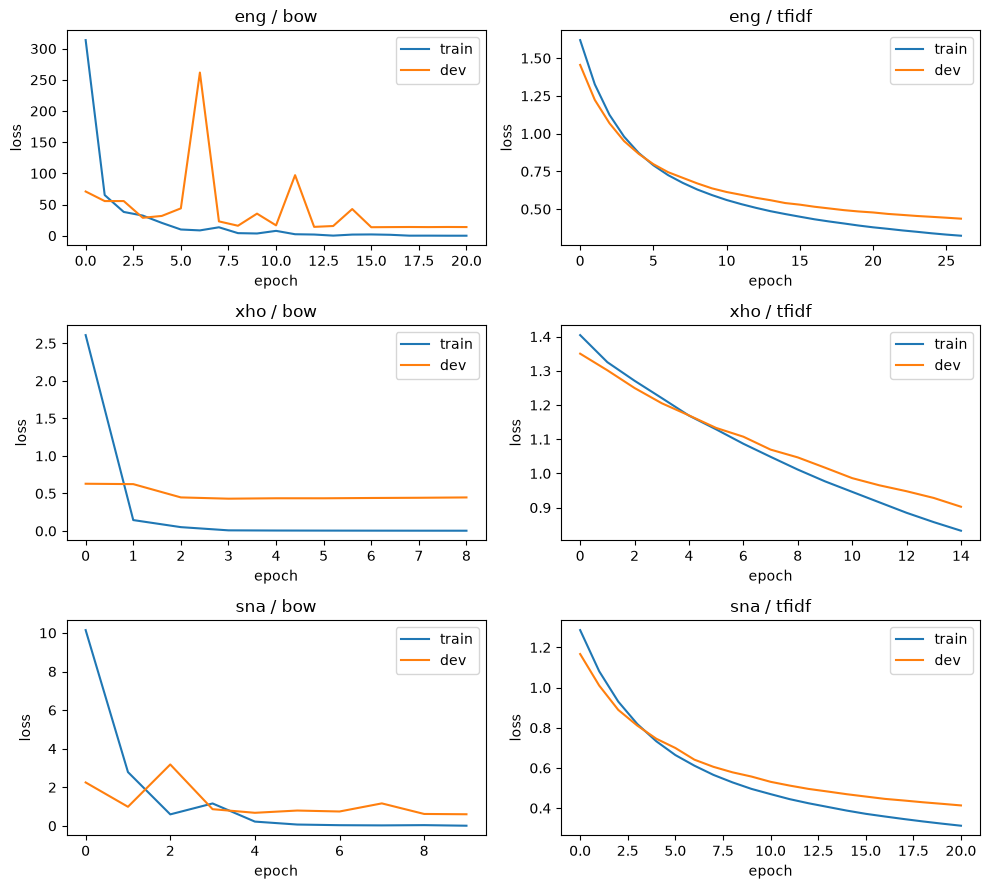

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

runs = pd.read_csv("grid_search_results.csv")
summary = pd.read_csv("grid_search_summary.csv")
runs["max_features"] = runs["max_features"].fillna(-1)  # -1 means no limit

# mean dev accuracy for each value of each hyperparameter
for col in ["min_df", "max_features", "lr", "batch_size"]:
    print(f"\n--- {col} ---")
    print(runs.groupby(["lang", "method", col]).dev_acc.mean().unstack().round(3))


fig, axes = plt.subplots(3, 2, figsize=(10, 9))
for i, lang in enumerate(LANGS):
    data = load_language(lang)
    for j, method in enumerate(METHODS):
        row = summary[(summary.lang == lang) & (summary.method == method)].iloc[0]
        mf = None if pd.isna(row.max_features) else int(row.max_features)
        X_train, y_train, X_dev, y_dev, _, _, le = build_features(
            data, method, int(row.min_df), mf)

        torch.manual_seed(42); np.random.seed(42)
        _, history, _ = train_track(X_train, y_train, X_dev, y_dev, len(le.classes_),
                                    lr=row.lr, batch_size=int(row.batch_size))

        best_epoch = int(np.argmax(history["dev_acc"])) + 1
        print(f"{lang}/{method}: best epoch {best_epoch} of {len(history['dev_acc'])}")

        ax = axes[i][j]
        ax.plot(history["train_loss"], label="train")
        ax.plot(history["dev_loss"], label="dev")
        ax.set_title(f"{lang} / {method}")
        ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

In [27]:
#Task 6 - weight analysis for english

"""
Retrains the best TF-IDF model and prints the highest-weighted words for each news category.
"""

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# # TF-IDF had the higher dev accuracy than BoW
LANG = "eng"
MIN_DF = 5
MAX_FEATURES = 10000
LR = 1.0
BATCH_SIZE = 32
TOP_K = 15


def main():
    torch.manual_seed(42);
    np.random.seed(42)
    data = load_language(LANG)

    vectorizer = TfidfVectorizer(
        tokenizer=tokenize, lowercase=False, token_pattern=None,
        ngram_range=(1, 2), min_df=MIN_DF, max_features=MAX_FEATURES,
        sublinear_tf=True,
    )
    X_train = vectorizer.fit_transform(data["train"]["full_text"])
    X_dev = vectorizer.transform(data["dev"]["full_text"])

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(data["train"]["category"])
    y_dev = label_encoder.transform(data["dev"]["category"])

    model, history, dev_acc = train_track(
        X_train, y_train, X_dev, y_dev, len(label_encoder.classes_),
        lr=LR, batch_size=BATCH_SIZE)
    print(f"trained: dev_acc={dev_acc:.4f}\n")

    # weight matrix: shape (n_classes, n_features). weight[c, f] is how
    # much feature f pushes the score for class c up (positive) or down.
    weights = model.linear.weight.detach().numpy()
    feature_names = np.array(vectorizer.get_feature_names_out())

    for class_idx, class_name in enumerate(label_encoder.classes_):
        class_weights = weights[class_idx]
        top_idx = np.argsort(class_weights)[::-1][:TOP_K]
        print(f"=== {class_name} ===")
        for idx in top_idx:
            print(f"  {feature_names[idx]:<25} {class_weights[idx]:.3f}")
        print()


if __name__ == "__main__":
    main()

trained: dev_acc=0.8835

=== business ===
  business                  2.596
  prices                    2.204
  energy                    1.971
  customers                 1.885
  bank                      1.877
  workers                   1.636
  price                     1.626
  company                   1.604
  businesses                1.543
  firm                      1.444
  rising                    1.421
  market                    1.374
  pay                       1.368
  costs                     1.353
  cost of                   1.333

=== entertainment ===
  music                     3.009
  show                      2.565
  film                      2.171
  artist                    2.167
  art                       2.151
  festival                  1.826
  song                      1.767
  singer                    1.757
  artists                   1.704
  theatre                   1.614
  tv                        1.607
  the show                  1.561
  arts           

In [36]:
#Task 7 - IsiXhosa class imbalance

"""
Tests upsampling and downsampling at different rates on
the best xho BoW model, picks each best rate on dev, and compares it with no sampling on test.
"""
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# Use the best isiXhosa BoW settings from Task 5.
# Only the sampling strategy is changed in Task 7.
LANG = "xho"
METHOD = "bow"
MIN_DF = 3
MAX_FEATURES = 10000
LR = 1.0
BATCH_SIZE = 32


def upsample(X_train, y_train, alpha, rng):
    """Sample minority classes more often."""
    class_counts = np.bincount(y_train)
    class_weight = 1.0 / (class_counts ** alpha)
    sample_weight = class_weight[y_train]
    sample_weight = sample_weight / sample_weight.sum()
    n = len(y_train)
    idx = rng.choice(n, size=n, replace=True, p=sample_weight)
    return X_train[idx], y_train[idx]


def downsample(X_train, y_train, rate, rng):
    """Remove some examples from majority classes."""
    class_counts = np.bincount(y_train)
    min_count = class_counts.min()
    target_counts = np.round(class_counts - rate * (class_counts - min_count)).astype(int)

    idx_parts = []
    for c, target in enumerate(target_counts):
        class_idx = np.where(y_train == c)[0]
        chosen = rng.choice(class_idx, size=target, replace=False)
        idx_parts.append(chosen)
    idx = np.concatenate(idx_parts)
    rng.shuffle(idx)
    return X_train[idx], y_train[idx]


def run_experiment(X_train, y_train, X_dev, y_dev, n_classes):
    model, history, dev_acc = train_track(
        X_train, y_train, X_dev, y_dev, n_classes, lr=LR, batch_size=BATCH_SIZE)
    return model, dev_acc


SEEDS = [42, 43, 44]


def run_averaged(X_train, y_train, X_dev, y_dev, n_classes):
    """Run training with a few fixed seeds and average the dev accuracy."""
    accs = []
    for seed in SEEDS:
        np.random.seed(seed)
        torch.manual_seed(seed)
        _, dev_acc = run_experiment(X_train, y_train, X_dev, y_dev, n_classes)
        accs.append(dev_acc)
    return float(np.mean(accs)), float(np.std(accs))


def main():
    rng = np.random.default_rng(0)
    data = load_language(LANG)
    X_train, y_train, X_dev, y_dev, X_test, y_test, label_encoder = build_features(
        data, METHOD, MIN_DF, MAX_FEATURES)
    n_classes = len(label_encoder.classes_)

    print("class counts (train):",
          dict(zip(label_encoder.classes_, np.bincount(y_train))))

    results = []
    loss_fn = nn.CrossEntropyLoss()

    # baseline: no resampling -This uses the same settings as the best Task 5 xho/bow model.
    mean_acc, std_acc = run_averaged(X_train, y_train, X_dev, y_dev, n_classes)
    results.append(dict(strategy="none", rate=0, dev_acc=mean_acc, dev_std=std_acc))
    print(f"\nbaseline (no sampling): dev_acc={mean_acc:.4f} (+/- {std_acc:.4f})")

    # 7.1 upsampling minority classes
    print("\n--- upsampling ---")
    for alpha in [0.5, 1.0, 1.5]:
        Xr, yr = upsample(X_train, y_train, alpha, rng)
        mean_acc, std_acc = run_averaged(Xr, yr, X_dev, y_dev, n_classes)
        results.append(dict(strategy="upsample", rate=alpha, dev_acc=mean_acc, dev_std=std_acc))
        print(f"alpha={alpha}: dev_acc={mean_acc:.4f} (+/- {std_acc:.4f})")

    # 7.2 downsampling majority classes
    print("\n--- downsampling ---")
    for rate in [0.5, 0.75, 1.0]:
        Xr, yr = downsample(X_train, y_train, rate, rng)
        mean_acc, std_acc = run_averaged(Xr, yr, X_dev, y_dev, n_classes)
        results.append(dict(strategy="downsample", rate=rate, dev_acc=mean_acc, dev_std=std_acc))
        print(f"rate={rate}: dev_acc={mean_acc:.4f} (+/- {std_acc:.4f})  (train size={len(yr)})")

    results_df = pd.DataFrame(results)
    print("\n=== all results (mean +/- std over 3 seeds) ===")
    print(results_df.to_string(index=False))

    # Choosin the best sampling rate using development accuracy -test set only used after choosing best rate.
    print("\n=== best config per strategy, evaluated on test ===")

    best_up = results_df[results_df.strategy == "upsample"].sort_values("dev_acc").iloc[-1]
    Xr, yr = upsample(X_train, y_train, best_up.rate, rng)
    model, dev_acc = run_experiment(Xr, yr, X_dev, y_dev, n_classes)
    _, test_acc = eval_loss_acc(model, X_test, y_test, loss_fn)
    print(f"upsample (alpha={best_up.rate}): dev_acc={dev_acc:.4f} test_acc={test_acc:.4f}")

    best_down = results_df[results_df.strategy == "downsample"].sort_values("dev_acc").iloc[-1]
    Xr, yr = downsample(X_train, y_train, best_down.rate, rng)
    model, dev_acc = run_experiment(Xr, yr, X_dev, y_dev, n_classes)
    _, test_acc = eval_loss_acc(model, X_test, y_test, loss_fn)
    print(f"downsample (rate={best_down.rate}): dev_acc={dev_acc:.4f} test_acc={test_acc:.4f}")

    model, dev_acc = run_experiment(X_train, y_train, X_dev, y_dev, n_classes)
    _, test_acc = eval_loss_acc(model, X_test, y_test, loss_fn)
    print(f"no sampling (baseline): dev_acc={dev_acc:.4f} test_acc={test_acc:.4f}")


if __name__ == "__main__":
    main()

class counts (train): {'business': np.int64(50), 'entertainment': np.int64(350), 'health': np.int64(70), 'politics': np.int64(215), 'sports': np.int64(347)}

baseline (no sampling): dev_acc=0.8866 (+/- 0.0032)

--- upsampling ---
alpha=0.5: dev_acc=0.8798 (+/- 0.0140)
alpha=1.0: dev_acc=0.8821 (+/- 0.0170)
alpha=1.5: dev_acc=0.8730 (+/- 0.0032)

--- downsampling ---
rate=0.5: dev_acc=0.8934 (+/- 0.0064)  (train size=640)
rate=0.75: dev_acc=0.8594 (+/- 0.0085)  (train size=445)
rate=1.0: dev_acc=0.7823 (+/- 0.0167)  (train size=250)

=== all results (mean +/- std over 3 seeds) ===
  strategy  rate  dev_acc  dev_std
      none  0.00 0.886621 0.003207
  upsample  0.50 0.879819 0.013978
  upsample  1.00 0.882086 0.016969
  upsample  1.50 0.873016 0.003207
downsample  0.50 0.893424 0.006414
downsample  0.75 0.859410 0.008484
downsample  1.00 0.782313 0.016663

=== best config per strategy, evaluated on test ===
upsample (alpha=1.0): dev_acc=0.9048 test_acc=0.8721
downsample (rate=0.5): dev_

In [37]:
# Recreating Task 7 data

data = load_language("xho")

X_train, y_train, X_dev, y_dev, X_test, y_test, label_encoder = build_features(
    data, "bow", 3, 10000
)

n_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
loss_fn = nn.CrossEntropyLoss()

rng = np.random.default_rng(0)

In [38]:
#Task 8 - Billingual

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder


# fixed, reused from Task 5 (xho best config) - only vocab size is varied here
METHOD = "bow"
MIN_DF = 3
LR = 1.0
BATCH_SIZE = 32
VOCAB_GRID = [2000, 5000, 20000, None]
SEEDS = [42, 43, 44]


def build_bilingual_features(lang_a, lang_b, max_features):
    data_a = load_language(lang_a)
    data_b = load_language(lang_b)

    combined_train = pd.concat([data_a["train"], data_b["train"]], ignore_index=True)
    combined_dev = pd.concat([data_a["dev"], data_b["dev"]], ignore_index=True)
    # which rows of the combined dev set belong to isiXhosa - used to check
    # isiXhosa's own validation accuracy, not just the pooled accuracy
    dev_is_xho = np.array([lang_a == "xho"] * len(data_a["dev"])
                           + [lang_b == "xho"] * len(data_b["dev"]))

    vectorizer = CountVectorizer(
        tokenizer=tokenize, lowercase=False, token_pattern=None,
        ngram_range=(1, 2), min_df=MIN_DF, max_features=max_features,
    )
    X_train = vectorizer.fit_transform(combined_train["full_text"])
    X_dev = vectorizer.transform(combined_dev["full_text"])

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(combined_train["category"])
    y_dev = label_encoder.transform(combined_dev["category"])

    return X_train, y_train, X_dev, y_dev, dev_is_xho, vectorizer, label_encoder, data_a


def xho_subset_acc(model, X_dev, y_dev, dev_is_xho,label_encoder):
    model.eval()
    with torch.no_grad():
        X_t = torch.from_numpy(X_dev[dev_is_xho].toarray()).float()
        y_t = torch.from_numpy(y_dev[dev_is_xho]).long()
        preds = torch.argmax(model(X_t), dim=1)
        return (preds == y_t).float().mean().item()


def run_averaged(X_train, y_train, X_dev, y_dev, n_classes, dev_is_xho, label_encoder):
    accs, xho_accs = [], []
    for seed in SEEDS:
        np.random.seed(seed)
        torch.manual_seed(seed)
        model, _, dev_acc = train_track(X_train, y_train, X_dev, y_dev, n_classes,
                                         lr=LR, batch_size=BATCH_SIZE)
        accs.append(dev_acc)
        xho_accs.append(xho_subset_acc(model, X_dev, y_dev, dev_is_xho, label_encoder))
    return float(np.mean(accs)), float(np.mean(xho_accs))


def run_pairing(other_lang, name):
    print(f"\n=== xho + {other_lang} ({name}) ===")
    results = []
    for max_features in VOCAB_GRID:
        X_train, y_train, X_dev, y_dev, dev_is_xho, vectorizer, label_encoder, xho_data = \
            build_bilingual_features("xho", other_lang, max_features)
        n_classes = len(label_encoder.classes_)
        overall_acc, xho_acc = run_averaged(
            X_train, y_train, X_dev, y_dev, n_classes, dev_is_xho, label_encoder)
        vocab_size = X_train.shape[1]
        results.append(dict(max_features=max_features, vocab_size=vocab_size,
                             overall_dev_acc=overall_acc, xho_dev_acc=xho_acc))
        print(f"max_features={max_features} (actual vocab={vocab_size}): "
              f"overall dev_acc={overall_acc:.4f}  xho-only dev_acc={xho_acc:.4f}")

    results_df = pd.DataFrame(results)
    best = results_df.sort_values("xho_dev_acc").iloc[-1]
    print(f"\nbest vocab size for xho: max_features={best.max_features} "
          f"(xho dev_acc={best.xho_dev_acc:.4f})")

    # retrain at the best vocab size, evaluate on isiXhosa's own test set


    best_vocab = None if pd.isna(best.max_features) else int(best.max_features)

    X_train, y_train, X_dev, y_dev, dev_is_xho, vectorizer, label_encoder, xho_data = \
    build_bilingual_features("xho", other_lang, best_vocab)
    n_classes = len(label_encoder.classes_)
    np.random.seed(42)
    torch.manual_seed(42)
    model, _, dev_acc = train_track(X_train, y_train, X_dev, y_dev, n_classes,
                                     lr=LR, batch_size=BATCH_SIZE)
    X_xho_test = vectorizer.transform(xho_data["test"]["full_text"])
    y_xho_test = label_encoder.transform(xho_data["test"]["category"])
    _, xho_test_acc = eval_loss_acc(model, X_xho_test, y_xho_test, nn.CrossEntropyLoss())
    print(f"xho test accuracy at best vocab size: {xho_test_acc:.4f}")

    return results_df, best, xho_test_acc


if __name__ == "__main__":
    results_sna, best_sna, test_sna = run_pairing("sna", "linguistically related")
    results_eng, best_eng, test_eng = run_pairing("eng", "linguistically unrelated")

    print("\n=== summary: isiXhosa test accuracy ===")
    print(f"xho + sna (best max_features={best_sna.max_features}): {test_sna:.4f}")
    print(f"xho + eng (best max_features={best_eng.max_features}): {test_eng:.4f}")


=== xho + sna (linguistically related) ===
max_features=2000 (actual vocab=2000): overall dev_acc=0.8655  xho-only dev_acc=0.8730
max_features=5000 (actual vocab=5000): overall dev_acc=0.8695  xho-only dev_acc=0.8753
max_features=20000 (actual vocab=20000): overall dev_acc=0.8906  xho-only dev_acc=0.8980
max_features=None (actual vocab=41508): overall dev_acc=0.8886  xho-only dev_acc=0.8866

best vocab size for xho: max_features=20000.0 (xho dev_acc=0.8980)
xho test accuracy at best vocab size: 0.8990

=== xho + eng (linguistically unrelated) ===
max_features=2000 (actual vocab=2000): overall dev_acc=0.8148  xho-only dev_acc=0.7528
max_features=5000 (actual vocab=5000): overall dev_acc=0.8417  xho-only dev_acc=0.8027
max_features=20000 (actual vocab=20000): overall dev_acc=0.8627  xho-only dev_acc=0.8549
max_features=None (actual vocab=120798): overall dev_acc=0.8670  xho-only dev_acc=0.8798

best vocab size for xho: max_features=nan (xho dev_acc=0.8798)
xho test accuracy at best voca

In [42]:
#Task 9

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def evaluate_test(y_test, y_pred, class_names, name):

    print(f"\n{name}")

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

    print("Micro Precision:", round(
        precision_score(y_test, y_pred, average="micro"), 4
    ))
    print("Macro Precision:", round(
        precision_score(y_test, y_pred, average="macro"), 4
    ))

    print("Micro Recall:", round(
        recall_score(y_test, y_pred, average="micro"), 4
    ))
    print("Macro Recall:", round(
        recall_score(y_test, y_pred, average="macro"), 4
    ))

    print("Micro F1:", round(
        f1_score(y_test, y_pred, average="micro"), 4
    ))
    print("Macro F1:", round(
        f1_score(y_test, y_pred, average="macro"), 4
    ))

    print("\nPer-class results:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=class_names,
        xticks_rotation=45
    )
    plt.title(name)
    plt.show()


Task 7 - No sampling
Accuracy: 0.9024
Micro Precision: 0.9024
Macro Precision: 0.8356
Micro Recall: 0.9024
Macro Recall: 0.7809
Micro F1: 0.9024
Macro F1: 0.7988

Per-class results:
               precision    recall  f1-score   support

     business     0.5333    0.5333    0.5333        15
entertainment     0.9320    0.9600    0.9458       100
       health     0.9167    0.5500    0.6875        20
     politics     0.8060    0.8710    0.8372        62
       sports     0.9900    0.9900    0.9900       100

     accuracy                         0.9024       297
    macro avg     0.8356    0.7809    0.7988       297
 weighted avg     0.9041    0.9024    0.8998       297



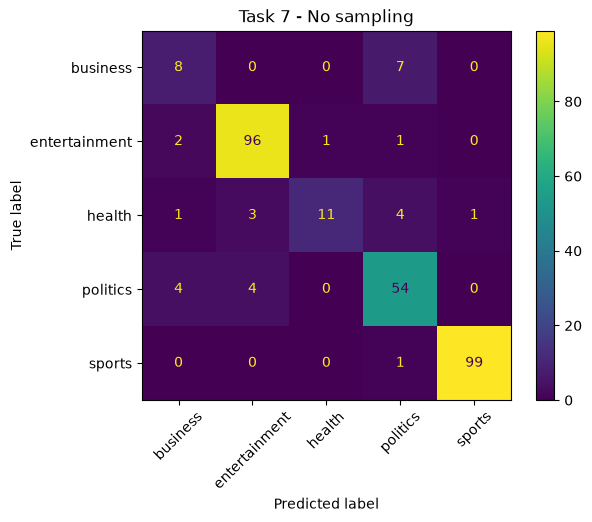

In [45]:
# Task 7 - No sampling
np.random.seed(42)
torch.manual_seed(42)
model, _ = run_experiment(
    X_train, y_train, X_dev, y_dev, n_classes
)

with torch.no_grad():
    X_tensor = torch.from_numpy(X_test.toarray()).float()
    y_pred = model.predict(X_tensor).numpy()

evaluate_test(
    y_test,
    y_pred,
    class_names,
    "Task 7 - No sampling"
)


Task 7 - Upsampling (alpha = 1.0)
Accuracy: 0.8923
Micro Precision: 0.8923
Macro Precision: 0.784
Micro Recall: 0.8923
Macro Recall: 0.7884
Micro F1: 0.8923
Macro F1: 0.7857

Per-class results:
               precision    recall  f1-score   support

     business     0.4706    0.5333    0.5000        15
entertainment     0.9400    0.9400    0.9400       100
       health     0.6842    0.6500    0.6667        20
     politics     0.8254    0.8387    0.8320        62
       sports     1.0000    0.9800    0.9899       100

     accuracy                         0.8923       297
    macro avg     0.7840    0.7884    0.7857       297
 weighted avg     0.8953    0.8923    0.8936       297



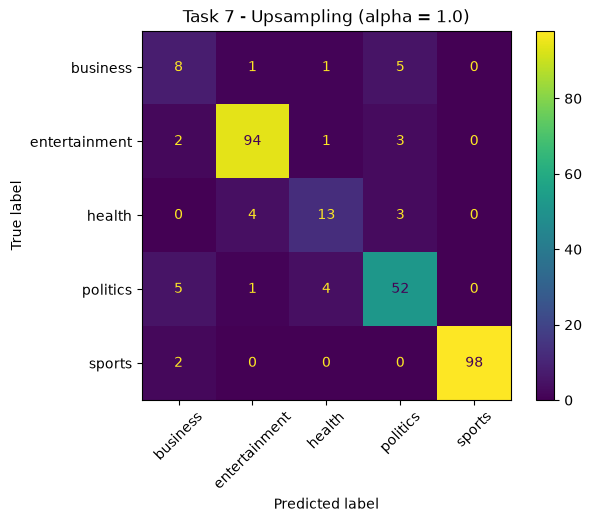

In [46]:
# Task 7 - Best upsampling

X_up, y_up = upsample(
    X_train, y_train, 1.0, rng
)
np.random.seed(42)
torch.manual_seed(42)
model, _ = run_experiment(
    X_up, y_up, X_dev, y_dev, n_classes
)

with torch.no_grad():
    X_tensor = torch.from_numpy(X_test.toarray()).float()
    y_pred = model.predict(X_tensor).numpy()

evaluate_test(
    y_test,
    y_pred,
    class_names,
    "Task 7 - Upsampling (alpha = 1.0)"
)


Task 7 - Downsampling (rate = 0.5)
Accuracy: 0.8923
Micro Precision: 0.8923
Macro Precision: 0.8044
Micro Recall: 0.8923
Macro Recall: 0.8436
Micro F1: 0.8923
Macro F1: 0.8194

Per-class results:
               precision    recall  f1-score   support

     business     0.5714    0.8000    0.6667        15
entertainment     0.9394    0.9300    0.9347       100
       health     0.6818    0.7500    0.7143        20
     politics     0.8393    0.7581    0.7966        62
       sports     0.9899    0.9800    0.9849       100

     accuracy                         0.8923       297
    macro avg     0.8044    0.8436    0.8194       297
 weighted avg     0.8996    0.8923    0.8944       297



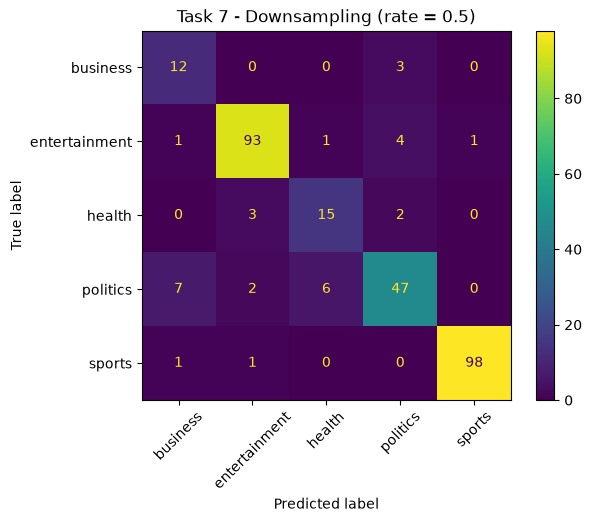

In [47]:
# Task 7 - Best downsampling

X_down, y_down = downsample(
    X_train, y_train, 0.5, rng
)
np.random.seed(42)
torch.manual_seed(42)
model, _ = run_experiment(
    X_down, y_down, X_dev, y_dev, n_classes
)

with torch.no_grad():
    X_tensor = torch.from_numpy(X_test.toarray()).float()
    y_pred = model.predict(X_tensor).numpy()

evaluate_test(
    y_test,
    y_pred,
    class_names,
    "Task 7 - Downsampling (rate = 0.5)"
)